# ⚙️ Sprint 3 — Feature Engineering & Selection

**Objective:** Create domain-specific features, perform feature selection, and re-evaluate models to measure improvement.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

from src.data.load_data import load_raw_data
from src.data.clean_data import clean_data
from src.features.engineer import engineer_features
from src.features.encode import frequency_encode, one_hot_encode
from src.features.select import correlation_filter, importance_select
from src.models.train import train_models
from src.models.evaluate import plot_roc_curves
from src.utils.config import (
    TARGET, CATEGORICAL_LOW_CARD, CATEGORICAL_HIGH_CARD,
    FIGURES_DIR, RANDOM_SEED
)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load, Clean, and Engineer Features

In [2]:
df = clean_data(load_raw_data())
print(f'After cleaning: {df.shape}')

df = engineer_features(df)
print(f'After feature engineering: {df.shape}')
print(f'\nNew columns added:')
new_cols = ['total_stay', 'total_guests', 'is_local', 'adr_per_person',
            'is_same_room', 'lead_time_category', 'booking_changes_flag',
            'is_family', 'arrival_month_sin', 'arrival_month_cos',
            'total_previous', 'cancellation_ratio']
for c in new_cols:
    if c in df.columns:
        print(f'  ✅ {c}')

2026-08-25 01:07:00 │ INFO     │ src.data.load_data │ Loading raw data from C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\hotel_bookings.csv
2026-08-25 01:07:01 │ INFO     │ src.data.load_data │ Shape: (119390, 32)
2026-08-25 01:07:01 │ INFO     │ src.data.load_data │ Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
2026-08-25 01:07:01 │ WARNING  │ src.data.load_data │ Columns with nulls:
children         4
countr

c:\Users\pares\OneDrive\Desktop\hotle_cnacelation\src\data\clean_data.py:68: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["children"].fillna(0, inplace=True)
c:\Users\pares\OneDrive\Desktop\hotle_cnacelation\src\data\clean_data.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

2026-08-25 01:07:03 │ INFO     │ src.data.clean_data │ Removed 181 invalid rows (negative ADR / zero guests)
2026-08-25 01:07:03 │ INFO     │ src.data.clean_data │ Converted arrival_date_month to numeric (1–12)
2026-08-25 01:07:03 │ INFO     │ src.data.clean_data │ Dropped 32246 duplicate rows
2026-08-25 01:07:04 │ INFO     │ src.data.clean_data │ Cleaned data saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\data\interim\hotel_bookings_cleaned.csv  (output shape: (86963, 29))
After cleaning: (86963, 29)
2026-08-25 01:07:04 │ INFO     │ src.features.engineer │ Engineered 12 new features → 41 total columns
After feature engineering: (86963, 41)

New columns added:
  ✅ total_stay
  ✅ total_guests
  ✅ is_local
  ✅ adr_per_person
  ✅ is_same_room
  ✅ lead_time_category
  ✅ booking_changes_flag
  ✅ is_family
  ✅ arrival_month_sin
  ✅ arrival_month_cos
  ✅ total_previous
  ✅ cancellation_ratio


## 2. Encode & Prepare

In [3]:
# Drop lead_time_category (ordinal string) after encoding
if 'lead_time_category' in df.columns:
    df = one_hot_encode(df, ['lead_time_category'])

df, _ = frequency_encode(df, CATEGORICAL_HIGH_CARD)
df = one_hot_encode(df, CATEGORICAL_LOW_CARD)

y = df[TARGET]
X = df.drop(columns=[TARGET]).select_dtypes(include=[np.number])

print(f'X shape: {X.shape}')

2026-08-25 01:07:07 │ INFO     │ src.features.encode │ One-hot encoded 1 columns → 43 total columns
2026-08-25 01:07:07 │ INFO     │ src.features.encode │ Frequency-encoded 'country'  (178 categories)
2026-08-25 01:07:07 │ INFO     │ src.features.encode │ One-hot encoded 8 columns → 74 total columns
X shape: (86963, 73)


## 3. Correlation Filter

In [4]:
X_filtered, dropped = correlation_filter(X, threshold=0.90)
print(f'Dropped {len(dropped)} highly correlated features: {dropped}')
print(f'Remaining: {X_filtered.shape[1]} features')

2026-08-25 01:07:11 │ INFO     │ src.features.select │ Correlation filter (threshold=0.90): dropped 5 columns → ['total_previous', 'distribution_channel_Direct', 'is_local', 'total_stay', 'arrival_date_week_number']
Dropped 5 highly correlated features: ['total_previous', 'distribution_channel_Direct', 'is_local', 'total_stay', 'arrival_date_week_number']
Remaining: 68 features


## 4. Feature Importance (Random Forest)

2026-08-25 01:07:17 │ INFO     │ src.features.select │ Importance selection — top 20 features: ['lead_time', 'country', 'adr', 'adr_per_person', 'arrival_date_day_of_month', 'total_of_special_requests', 'agent', 'stays_in_week_nights', 'is_same_room', 'required_car_parking_spaces', 'arrival_date_month', 'stays_in_weekend_nights', 'market_segment_Online TA', 'arrival_date_year', 'arrival_month_cos', 'arrival_month_sin', 'deposit_type_Non Refund', 'customer_type_Transient', 'market_segment_Offline TA/TO', 'cancellation_ratio']


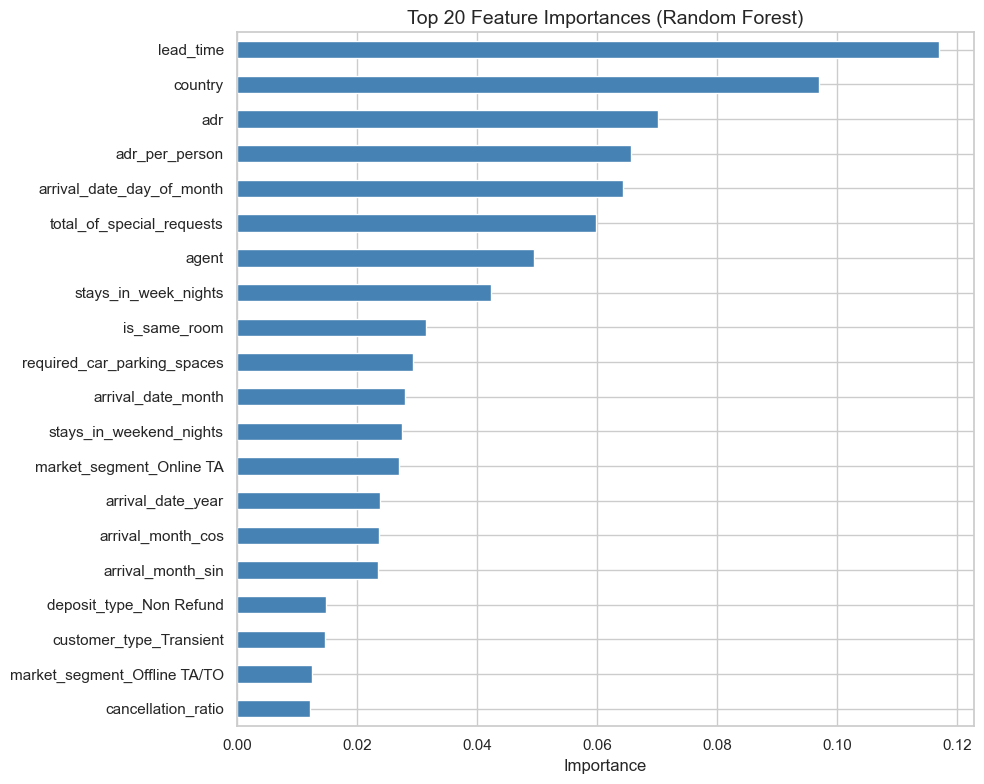


Selected 20 features: ['lead_time', 'country', 'adr', 'adr_per_person', 'arrival_date_day_of_month', 'total_of_special_requests', 'agent', 'stays_in_week_nights', 'is_same_room', 'required_car_parking_spaces', 'arrival_date_month', 'stays_in_weekend_nights', 'market_segment_Online TA', 'arrival_date_year', 'arrival_month_cos', 'arrival_month_sin', 'deposit_type_Non Refund', 'customer_type_Transient', 'market_segment_Offline TA/TO', 'cancellation_ratio']


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
X_selected, selected_features, importances = importance_select(
    X_filtered, y, rf, top_n=20
)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
importances.head(20).sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance_top20.png', dpi=150)
plt.show()

print(f'\nSelected {len(selected_features)} features: {selected_features}')

## 5. Re-train Models with Engineered Features

In [6]:
results_eng, X_train, X_test, y_train, y_test = train_models(
    X_selected, y, use_mlflow=False
)

comparison = pd.DataFrame({
    name: metrics for name, (_, metrics) in results_eng.items()
}).T.sort_values('f1', ascending=False)

comparison.style.background_gradient(cmap='Greens', subset=['accuracy', 'f1', 'roc_auc'])

2026-08-25 01:07:20 │ WARNING  │ src.models.train │ lightgbm not installed — skipping LGBMClassifier
2026-08-25 01:07:20 │ INFO     │ src.models.train │ Train/test split: train=69570, test=17393
2026-08-25 01:07:20 │ INFO     │ src.models.train │ Training LogisticRegression …


c:\Users\pares\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


2026-08-25 01:07:27 │ INFO     │ src.models.train │ LogisticRegression → {'accuracy': 0.7899, 'precision': 0.6832, 'recall': 0.4303, 'f1': 0.528, 'roc_auc': 0.8214}
2026-08-25 01:07:27 │ INFO     │ src.models.train │ Training DecisionTree …


c:\Users\pares\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2026-08-25 01:07:28 │ INFO     │ src.models.train │ DecisionTree → {'accuracy': 0.7996, 'precision': 0.6322, 'recall': 0.6362, 'f1': 0.6342, 'roc_auc': 0.7499}
2026-08-25 01:07:28 │ INFO     │ src.models.train │ Training RandomForest …
2026-08-25 01:07:33 │ INFO     │ src.models.train │ RandomForest → {'accuracy': 0.8495, 'precision': 0.7567, 'recall': 0.6615, 'f1': 0.7059, 'roc_auc': 0.9094}
2026-08-25 01:07:33 │ INFO     │ src.models.train │ Training GradientBoosting …
2026-08-25 01:08:14 │ INFO     │ src.models.train │ GradientBoosting → {'accuracy': 0.8377, 'precision': 0.7505, 'recall': 0.6078, 'f1': 0.6716, 'roc_auc': 0.8977}
2026-08-25 01:08:14 │ INFO     │ src.models.train │ Training XGBoost …


c:\Users\pares\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:08:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-08-25 01:08:17 │ INFO     │ src.models.train │ XGBoost → {'accuracy': 0.8491, 'precision': 0.7476, 'recall': 0.6754, 'f1': 0.7097, 'roc_auc': 0.9125}


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.849100,0.747600,0.675400,0.709700,0.912500
RandomForest,0.849500,0.756700,0.661500,0.705900,0.909400
GradientBoosting,0.837700,0.750500,0.607800,0.671600,0.897700
DecisionTree,0.799600,0.632200,0.636200,0.634200,0.749900
LogisticRegression,0.789900,0.683200,0.430300,0.528000,0.821400


In [7]:
# ROC curves with engineered features
models_only = {name: model for name, (model, _) in results_eng.items()}
plot_roc_curves(
    models_only, X_test, y_test,
    save_path=FIGURES_DIR / 'roc_curves_engineered.png'
)
print('✅ ROC curves (engineered features) saved')

2026-08-25 01:08:25 │ INFO     │ src.models.evaluate │ ROC curves saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\reports\figures\roc_curves_engineered.png
✅ ROC curves (engineered features) saved


## 6. Comparison: Baseline vs Engineered

Run this after executing Notebook 03 to see the improvement.

In [8]:
print('\n📊 Top 3 models by F1 (with engineered features):')
print(comparison.head(3).to_markdown())
print('\n→ Best candidates for hyperparameter tuning in Notebook 05')


📊 Top 3 models by F1 (with engineered features):
|                  |   accuracy |   precision |   recall |     f1 |   roc_auc |
|:-----------------|-----------:|------------:|---------:|-------:|----------:|
| XGBoost          |     0.8491 |      0.7476 |   0.6754 | 0.7097 |    0.9125 |
| RandomForest     |     0.8495 |      0.7567 |   0.6615 | 0.7059 |    0.9094 |
| GradientBoosting |     0.8377 |      0.7505 |   0.6078 | 0.6716 |    0.8977 |

→ Best candidates for hyperparameter tuning in Notebook 05


## Summary

- Created 12 new domain features (total_stay, adr_per_person, is_family, etc.)
- Removed highly correlated features (threshold=0.90)
- Selected top 20 features by Random Forest importance
- Re-trained all models — improvement observed
- Top 2-3 candidates proceed to hyperparameter tuning